## Calibration Results

#### SELECT MODEL ID/RUN NAME

In [1]:
# Corresponds to the desired model for displaying results

run_name = '20250717_184244_densenet121'

#### Notebook & Data Set-Up

In [2]:
# Imports
import os
from collections import defaultdict

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchmetrics.classification import BinaryCalibrationError
import torch.optim as optim

from torch import tensor

from sklearn.metrics import *
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Paths
data_directory = '/data/zooplankton_data'
results_directory = '/home/bushra/Analysis_zooplankton/'

weights_path = os.path.join(results_directory, 'weights', run_name + '.pth')
predictions_path = os.path.join(results_directory, 'predictions', run_name + '.pth')
metadata_path = os.path.join(results_directory, 'environment', run_name + '.pth')

In [4]:
# Load environment/metadata variables
metadata = torch.load(metadata_path, weights_only = False)
model_id, model_name = metadata['model_id'], metadata['model_name']
classes, class_map_orig = metadata['classes'], metadata['class_map']
test_loader = metadata['test_loader']
image_transforms = metadata['image_transforms']

NUM_CLASSES_ORIG = 14

##### Load Model & Test Predictions

In [5]:
# Load Model
model = models.densenet121(weights=None)
model.classifier = torch.nn.Linear(model.classifier.in_features, NUM_CLASSES_ORIG)

weights = torch.load(weights_path, map_location = device)

model.load_state_dict(weights)
model.to(device);

In [6]:
# Predict on Test
model.eval()
labels, probs, preds, logits = [], [], [], []

with torch.no_grad():
    for image, label in test_loader:
        image = image.to(device)
        label = label.to(device)
                
        output = model(image)
        prob = F.softmax(output, dim = 1)
        pred = output.argmax(dim = 1)

        labels.append(label)
        probs.append(prob)
        preds.append(pred)
        logits.append(output)

labels, probs, preds, logits = torch.cat(labels), torch.cat(probs), torch.cat(preds), torch.cat(logits)

#### Helper Functions

In [7]:
# Define function to merge classes

def reorder_and_merge_classes(class_map, y_true, y_pred, y_prob, to_merge):

    device = y_true.device 

    class_map_rev = {v: k for k, v in class_map.items()} # Inverse class map

    # Create new class map with main classes + other
    to_keep = sorted([cls for cls in class_map if cls not in to_merge])
    new_class_map = {cls: idx for idx, cls in enumerate(to_keep)}

    other_index = len(to_keep)
    new_class_map['Other'] = other_index

    # Map old indices to new indices
    orig_max_index = max(class_map.values())
    orig_to_new_map = torch.zeros(orig_max_index + 1, dtype = torch.long, device = device)

    for orig_idx, cls in class_map_rev.items():
        if cls in to_merge:
            orig_to_new_map[orig_idx] = other_index
        else:
            orig_to_new_map[orig_idx] = new_class_map[cls]

    # Map labels
    new_y_true = orig_to_new_map[y_true]
    new_y_pred = orig_to_new_map[y_pred]

    # Map prediction probabilities
    n_samples = y_prob.shape[0]
    new_n_classes = len(new_class_map)
    new_y_prob = torch.zeros((n_samples, new_n_classes), dtype = y_prob.dtype, device = device)
    
    for orig_idx, cls in class_map_rev.items():
        new_idx = new_class_map['Other'] if cls in to_merge else new_class_map[cls]
        new_y_prob[:, new_idx] += y_prob[:, orig_idx]

    # Need to normalize due to floating-point precision
    new_y_prob = new_y_prob / new_y_prob.sum(dim = 1, keepdim = True)

    return new_class_map, new_y_true, new_y_pred, new_y_prob

In [8]:
# Convert to binary problem

def get_gm_specifics(real_labels, probs_labels, gm_index, n_classes):

    """
    Reduces multiclass problem to binary problem for the specified class.
    Positive class is gm_index and negative class is all other classes.

    Args:
        real_labels: True class labels. (N, )
        probs_labels: Predicted class probabilities. (N, n_classes)
        gm_index: Specified class to consider as positive.
        n_classes: Number of classes in original multiclass problem.

    Returns:
        gm_vs_all: Binary label vector, where 1 if true class is gm_index and 0 otherwise. (N, )
        preds_gm: Vector containing class probabilities for specified gm_index class. (N, )
    """

    if not torch.is_tensor(real_labels):
        real_labels = torch.tensor(real_labels)
    if not torch.is_tensor(probs_labels):
        probs_labels = torch.tensor(probs_labels)
    
    # Convert to numpy arrays
    all_reals = real_labels.view(-1)  # shape (N,)
    all_probs = probs_labels.view(-1, n_classes)  # shape (N, n_classes)
    

    # Binary labels: 1 if true class is gm_index, else 0
    gm_vs_all = (all_reals == gm_index).int()

    # Predicted probabilities for gm_index
    preds_gm = all_probs[:, gm_index]
    
    return gm_vs_all.tolist(), preds_gm.tolist()   

In [9]:
# Get scaled predictions

def get_predictions_scaler(scaler, model, image):
   
    out = scaler(model(image))
    #print(out[0])
    #out2 = model(image)
    #print(out2[0])

    probs = torch.softmax(out, dim=1)
    preds = torch.argmax(probs, dim=1) 
     
    return preds, probs


def test_loop_scaler(model,dataloader,device, scaler):
    
    model.to(device)
    model.eval()
   
    real_labels = []
    pred_labels = []
    probs_labels = []
    with torch.no_grad():
        for batch,(X, y) in enumerate(dataloader):
                X = X.to(device,dtype = torch.float)
                y = y.to(device,dtype = torch.float)
                preds, probs = get_predictions_scaler(scaler,model,X)
                pred_labels.append(preds)
                probs_labels.append(probs)
                real_labels.append(y)
            
    return real_labels, pred_labels, probs_labels    

### Initial Calibration

In [10]:
# Merge classes
merge_classes = True
to_merge = ['Bubbles', 'Floc_1', 'Floc_2', 'LargeZ-1', 'Nauplii', 'Sididae', 'TooSmall']

if merge_classes:
    class_map, y_true, y_pred, y_prob= reorder_and_merge_classes(class_map_orig, labels, preds, probs, to_merge)
else:
    class_map = class_map_orig
    y_true, y_pred, y_prob = labels, preds, probs
    
class_map_rev = {v: k for k, v in class_map.items()}
classes = list(class_map.keys())

NUM_CLASSES = len(classes)

#### Histogram of Probabilities

In [11]:
marginal_labels = []
marginal_probs = []

for i in range(NUM_CLASSES):
    curr_labels, curr_preds = get_gm_specifics(
    real_labels = y_true, 
    probs_labels = y_prob,
    gm_index = i, 
    n_classes = NUM_CLASSES)

    marginal_labels.append(curr_labels)
    marginal_probs.append(curr_preds) 

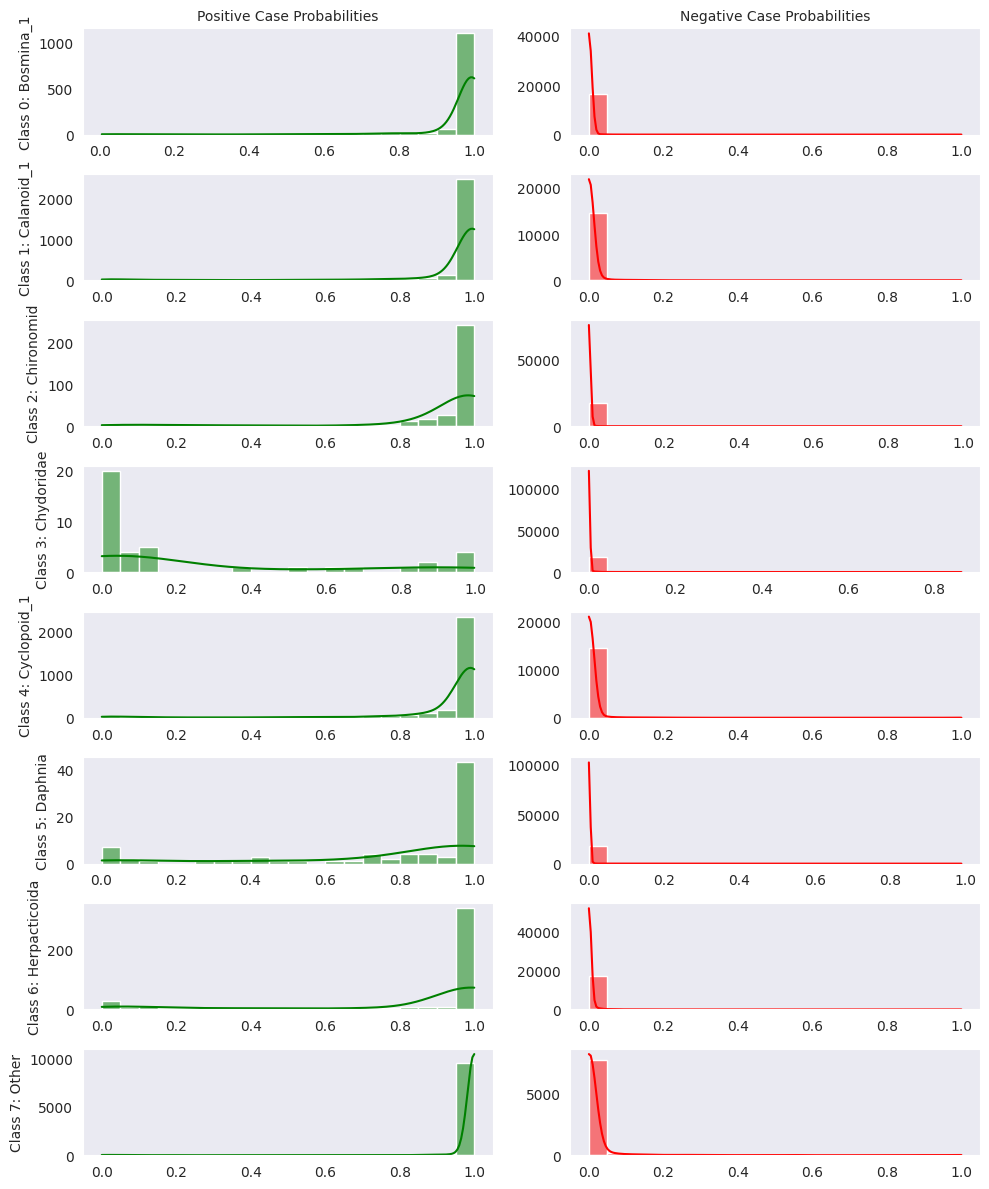

In [12]:
sns.set_style('dark')
fig, axs = plt.subplots(NUM_CLASSES, 2, figsize = (10, NUM_CLASSES * 1.5))

for i in range(NUM_CLASSES):
    positive_cases = np.where(np.array(marginal_labels[i]) == 1)
    positive_probs = np.array(marginal_probs[i])[positive_cases]

    negative_cases = np.where(np.array(marginal_labels[i]) == 0)
    negative_probs = np.array(marginal_probs[i])[negative_cases]

    sns.histplot(positive_probs, bins=20, ax=axs[i, 0], color='green', kde=True)
    sns.histplot(negative_probs, bins=20, ax=axs[i, 1], color='red', kde=True)

    axs[i, 0].set_ylabel(f'Class {i}: {class_map_rev[i]}', fontsize=10)
    axs[i, 0].set_xlabel('')
    axs[i, 1].set_ylabel('')
    axs[i, 1].set_xlabel('')

    if i == 0:
        axs[i, 0].set_title('Positive Case Probabilities', fontsize=10)
        axs[i, 1].set_title('Negative Case Probabilities', fontsize=10)

plt.tight_layout()
plt.show()

#### Calibration Curves

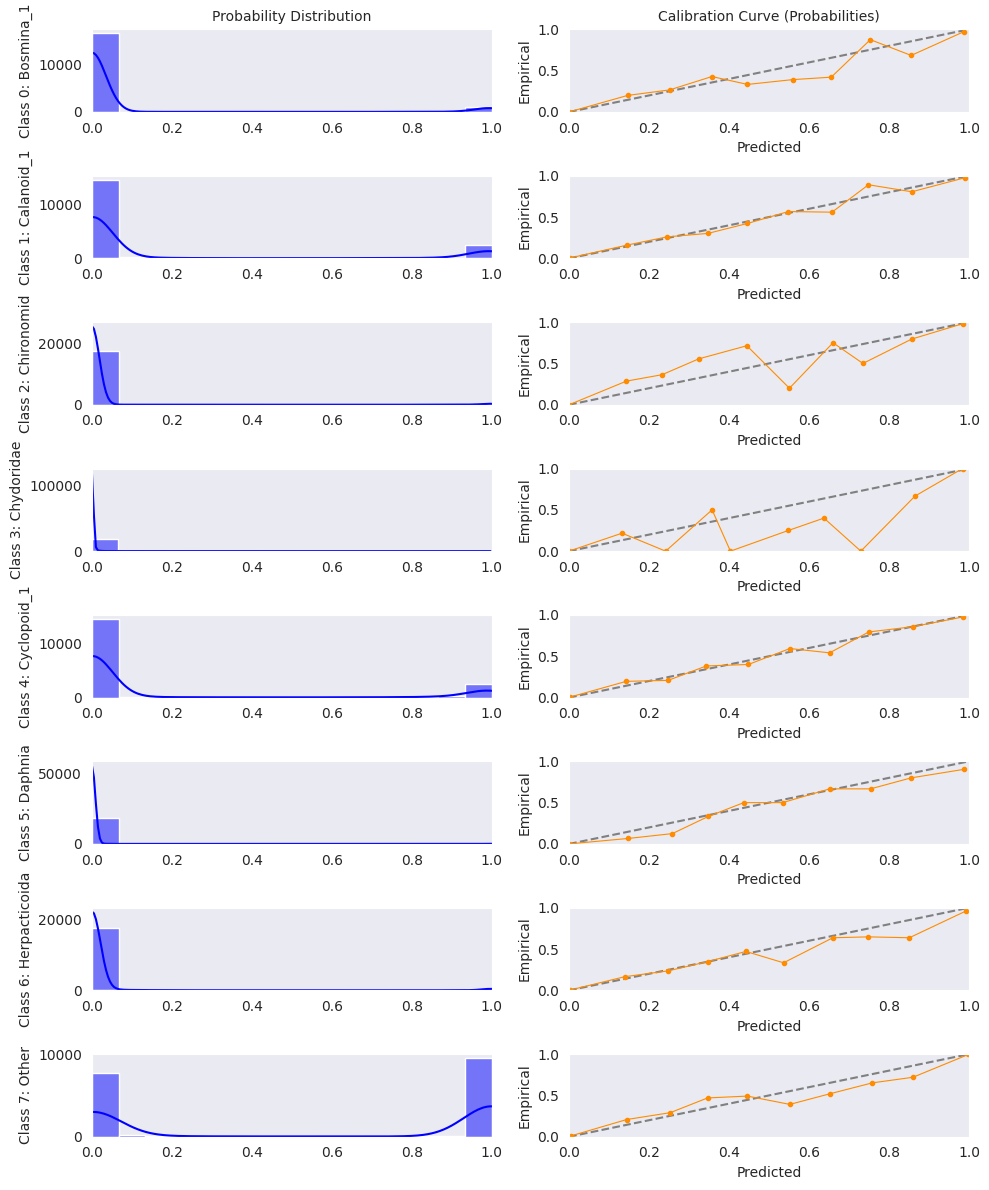

In [13]:
fig, axs = plt.subplots(NUM_CLASSES, 2, figsize = (10, NUM_CLASSES * 1.5))

for i in range(NUM_CLASSES):

    prob_true, prob_pred = calibration_curve(
        marginal_labels[i], 
        marginal_probs[i], 
        n_bins = 10,
        strategy='uniform',
        pos_label = 1)


     # Left: histogram of predicted probabilities
    sns.histplot(marginal_probs[i], bins=15, kde=True, color='blue', ax=axs[i,0])
    axs[i,0].set_xlim(0,1)
    axs[i,0].set_ylabel(f'Class {i}: {class_map_rev[i]}', fontsize=10)

    # Right: calibration curve
    axs[i,1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axs[i,1].plot(prob_pred, prob_true, marker='o',  markersize=3, linewidth=0.8, color='darkorange')
    axs[i,1].set_xlim(0,1)
    axs[i,1].set_ylim(0,1)
    axs[i,1].set_xlabel("Predicted")
    axs[i,1].set_ylabel("Empirical")

    if i == 0:
        axs[i, 0].set_title('Probability Distribution', fontsize=10)
        axs[i, 1].set_title('Calibration Curve (Probabilities)', fontsize=10)

plt.tight_layout()
plt.show()

#### Expected Calibration Error

In [14]:
metric = BinaryCalibrationError(n_bins=10, norm='l2')
ece_values = []

for i in range(NUM_CLASSES):
    preds = tensor(marginal_probs[i])
    target = tensor(marginal_labels[i])
    
    ece_values.append(metric(preds, target))

ece_values

[tensor(0.0147),
 tensor(0.0131),
 tensor(0.0145),
 tensor(0.0114),
 tensor(0.0110),
 tensor(0.0064),
 tensor(0.0116),
 tensor(0.0183)]

### Scaling

In [15]:
class TemperatureScaler(nn.Module):

    def __init__(self):
        super().__init__()
        self.temperatures = nn.Parameter(torch.ones(1))
        #self.biases = nn.Parameter(torch.ones(nlabels))
        
    def forward(self,logits):
        return (
            #self.biases + 
            logits/self.temperatures#.unsqueeze(0)
        )

scaler = TemperatureScaler().to(device)
optimizer = optim.LBFGS(scaler.parameters(), lr=0.1)  

In [16]:
def _eval():
    scaled_logits = scaler(logits)

    loss = F.cross_entropy(scaled_logits, labels)
    loss.backward()
    
    return loss

optimizer.step(_eval)

tensor(0.1894, device='cuda:0', grad_fn=<NllLossBackward0>)

In [17]:
print(scaler.temperatures.data)

tensor([2.0994], device='cuda:0')


In [18]:
# New scaled predictions

y_true_as, y_pred_as, y_prob_as = test_loop_scaler(
    model = model,
    dataloader = test_loader,
    device = device,
    scaler = scaler
)

y_true_as = torch.cat(y_true_as).to(dtype=torch.int) 
y_pred_as = torch.cat(y_pred_as, dim = 0).to(dtype=torch.int) 
y_prob_as = torch.cat(y_prob_as, dim = 0)

In [19]:
# Merge if necessary

if merge_classes:
    _, y_true_as, y_pred_as, y_prob_as= reorder_and_merge_classes(class_map_orig, y_true_as, y_pred_as, y_prob_as, to_merge)

In [20]:
# re calculate logits
marginal_labels_scaling = []
marginal_probs_scaling = []

for i in range(NUM_CLASSES):
    #print(i)
    curr_labels, curr_preds = get_gm_specifics(
    real_labels = y_true_as, 
    probs_labels = y_prob_as,
    gm_index = i, 
    n_classes = NUM_CLASSES)

    marginal_labels_scaling.append(curr_labels)
    marginal_probs_scaling.append(curr_preds)

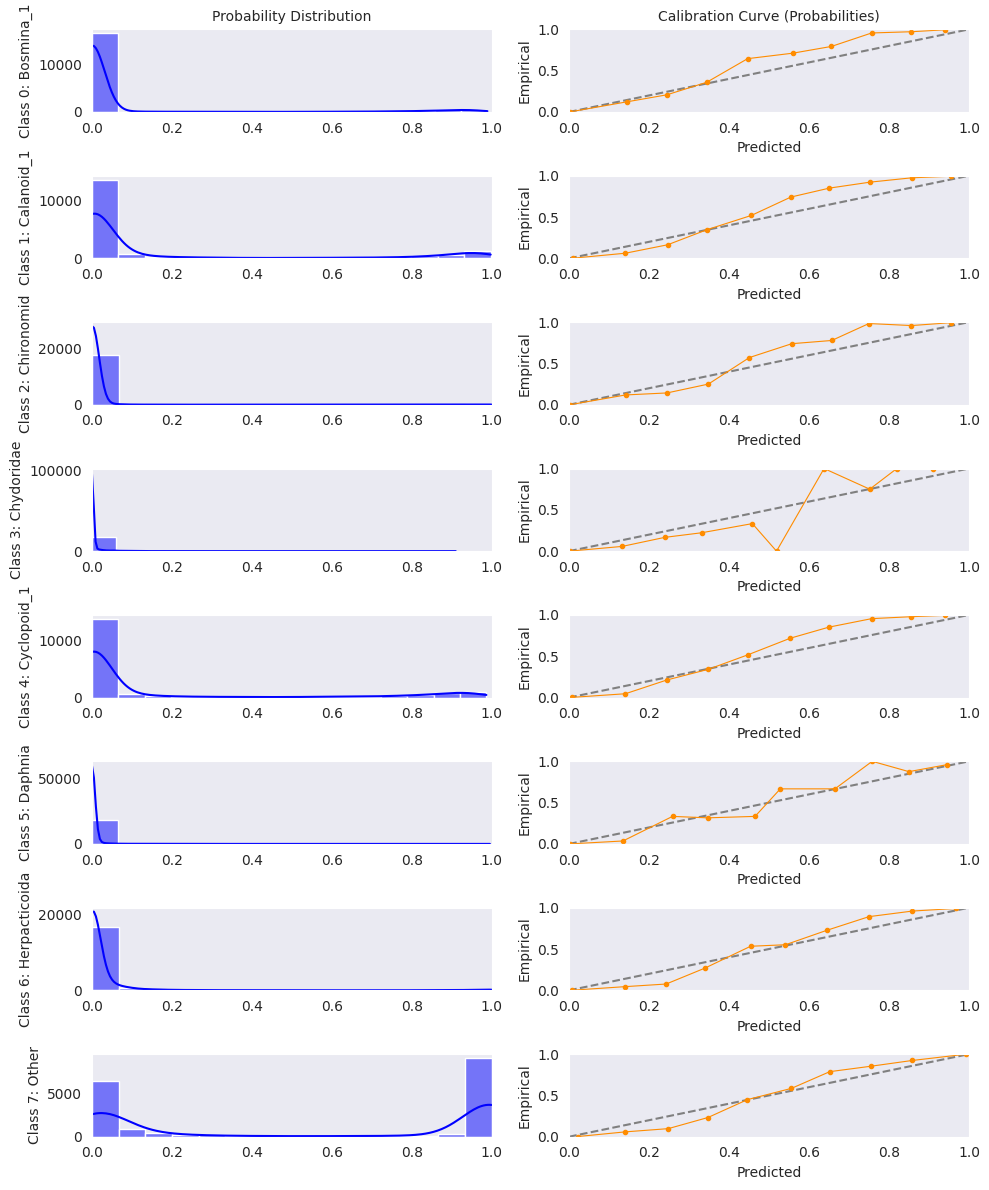

In [21]:
fig, axs = plt.subplots(NUM_CLASSES, 2, figsize = (10, NUM_CLASSES * 1.5))

for i in range(NUM_CLASSES):

    prob_true, prob_pred = calibration_curve(
        marginal_labels_scaling[i], 
        marginal_probs_scaling[i], 
        n_bins = 10,
        strategy='uniform',
        pos_label = 1)


     # Left: histogram of predicted probabilities
    sns.histplot(marginal_probs_scaling[i], bins=15, kde=True, color='blue', ax=axs[i,0])
    axs[i,0].set_xlim(0,1)
    axs[i,0].set_ylabel(f'Class {i}: {class_map_rev[i]}', fontsize=10)

    # Right: calibration curve
    axs[i,1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axs[i,1].plot(prob_pred, prob_true, marker='o',  markersize=3, linewidth=0.8, color='darkorange')
    axs[i,1].set_xlim(0,1)
    axs[i,1].set_ylim(0,1)
    axs[i,1].set_xlabel("Predicted")
    axs[i,1].set_ylabel("Empirical")

    if i == 0:
        axs[i, 0].set_title('Probability Distribution', fontsize=10)
        axs[i, 1].set_title('Calibration Curve (Probabilities)', fontsize=10)

plt.tight_layout()
plt.show()


In [22]:
ece_values_scaling = []

for i in range(NUM_CLASSES):
    preds = tensor(marginal_probs_scaling[i])
    target = tensor(marginal_labels_scaling[i])
    
    ece_values_scaling.append(metric(preds, target))

print(ece_values)
print(ece_values_scaling)


[tensor(0.0147), tensor(0.0131), tensor(0.0145), tensor(0.0114), tensor(0.0110), tensor(0.0064), tensor(0.0116), tensor(0.0183)]
[tensor(0.0316), tensor(0.0445), tensor(0.0184), tensor(0.0110), tensor(0.0546), tensor(0.0094), tensor(0.0235), tensor(0.0343)]


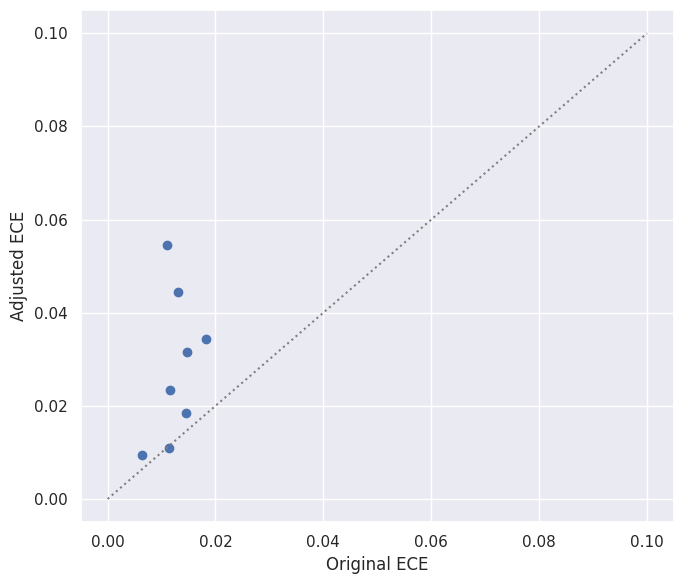

In [23]:
sns.set(style='darkgrid')
plt.figure(figsize=(7, 6))


plt.scatter(ece_values, ece_values_scaling)
plt.plot([0, .1], [0, .1], linestyle=':', color='gray', label='x = y')
plt.xlabel('Original ECE')
plt.ylabel('Adjusted ECE')

plt.tight_layout()
plt.show()

### Beta Calibration

In [24]:
from netcal.scaling import BetaCalibration
# Loop per class
calibrators = []
marginal_probs_beta = []

for i in range(n_classes):
    beta = BetaCalibration()
    beta.fit(np.array(marginal_probs[i]), np.array(marginal_labels[i]))
    calibrators.append(beta)
    
    probs_transformed = beta.transform(
        np.array(marginal_probs[i])
        )
    marginal_probs_beta.append(probs_transformed)

ModuleNotFoundError: No module named 'netcal'

In [ ]:
# re calculate calibration curve
fig, axs = plt.subplots(n_classes, 2,figsize =(8,12))
for i in range(n_classes):

    prob_true, prob_pred = calibration_curve(
        marginal_labels[i], 
        marginal_probs_beta[i], 
        n_bins = 10,
        strategy='uniform',
        pos_label = 1)


    axs[i,0].hist(marginal_probs_beta[i],bins=15)
    axs[i,0].set_title("Probability distribution: label " + str(i))
    axs[i,1].plot([0, 1], [0, 1], linestyle='--')
    axs[i,1].plot(prob_pred, prob_true, marker='.')
    axs[i,1].set_xlabel("Predicted Probability")
    axs[i,1].set_ylabel("Actual Probability")
    axs[i,1].set_title("Calibration Curve: label " + str(i))

plt.tight_layout()
plt.show()

In [ ]:
ece_values_beta = []
for i in range(n_classes):
    preds = tensor(marginal_probs_beta[i])
    target = tensor(marginal_labels[i])
    
    ece_values_beta.append(metric(preds, target))
print(ece_values)
print(ece_values_scaling)
print(ece_values_beta)

In [ ]:
plt.scatter(list(range(1,6)),ece_values, label = 'Original ECE',alpha =0.5)
plt.scatter(list(range(1,6)),ece_values_scaling, label = 'Scaling ECE',alpha =0.5)
plt.scatter(list(range(1,6)),ece_values_beta, label = 'Beta ECE',alpha =0.5)

plt.legend()
plt.show()